## Let's create a small CNN from scratch

Input shape: (9, 9)


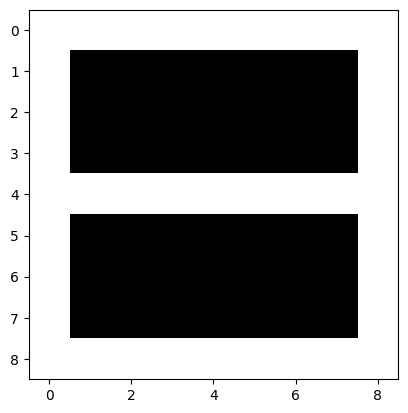

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Step 1: Input image — number "8"
# -------------------------
image = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1]
])

print("Input shape:", image.shape)

plt.imshow(image, cmap='gray')

In [23]:

# -------------------------
# Step 2: Convolution (3x3 filter)
# -------------------------
kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])  # edge detector

output_shape = image.shape[0] - kernel.shape[0] + 1
conv_output = np.zeros((output_shape, output_shape))

for i in range(output_shape):
    for j in range(output_shape):
        region = image[i:i+3, j:j+3]
        conv_output[i, j] = np.sum(region * kernel)

print("\nAfter convolution:\n", conv_output)

# -------------------------
# Step 3: ReLU activation
# -------------------------
relu_output = np.maximum(conv_output, 0)
print("\nAfter ReLU:\n", relu_output)

# -------------------------
# Step 4: Max pooling (2x2, safe bounds)
# -------------------------
pool_size = 2
pooled_rows = relu_output.shape[0] // pool_size
pooled_cols = relu_output.shape[1] // pool_size
pooled_output = np.zeros((pooled_rows, pooled_cols))

for i in range(pooled_rows):
    for j in range(pooled_cols):
        region = relu_output[i*pool_size:(i+1)*pool_size, j*pool_size:(j+1)*pool_size]
        pooled_output[i, j] = np.max(region)

print("\nAfter max pooling:\n", pooled_output)

# -------------------------
# Step 5: Fully connected (flatten + output)
# -------------------------
flattened = pooled_output.flatten()
print("\nFlattened feature vector:", flattened)

# Tiny dense layer (2 output classes)
weights = np.random.randn(2, len(flattened))
biases = np.random.randn(2)
output = np.dot(weights, flattened) + biases

print("\nFinal output (class scores):", output)



After convolution:
 [[ 2.  0.  0.  0.  0.  0. -2.]
 [ 3.  0.  0.  0.  0.  0. -3.]
 [ 2.  0.  0.  0.  0.  0. -2.]
 [ 2.  0.  0.  0.  0.  0. -2.]
 [ 2.  0.  0.  0.  0.  0. -2.]
 [ 3.  0.  0.  0.  0.  0. -3.]
 [ 2.  0.  0.  0.  0.  0. -2.]]

After ReLU:
 [[2. 0. 0. 0. 0. 0. 0.]
 [3. 0. 0. 0. 0. 0. 0.]
 [2. 0. 0. 0. 0. 0. 0.]
 [2. 0. 0. 0. 0. 0. 0.]
 [2. 0. 0. 0. 0. 0. 0.]
 [3. 0. 0. 0. 0. 0. 0.]
 [2. 0. 0. 0. 0. 0. 0.]]

After max pooling:
 [[3. 0. 0.]
 [2. 0. 0.]
 [3. 0. 0.]]

Flattened feature vector: [3. 0. 0. 2. 0. 0. 3. 0. 0.]

Final output (class scores): [7.01178404 0.93108733]


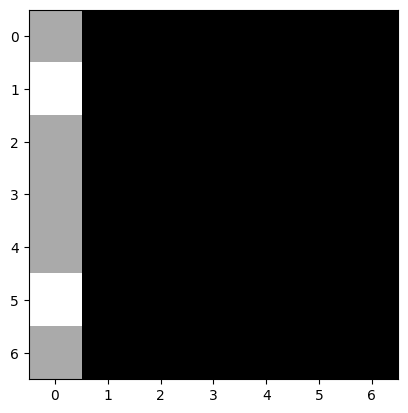

In [24]:
# What does the output feature map look like?

plt.imshow(relu_output, cmap='gray')

What if we change the kernel?

In [25]:
import numpy as np

# -------------------------
# Step 1: Input image — number "8"
# -------------------------
image = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1]
])
print("Input shape:", image.shape)

# -------------------------
# Step 2: Convolution (3x3 filter)
# -------------------------
kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])  # edge detector

output_shape = image.shape[0] - kernel.shape[0] + 1
conv_output = np.zeros((output_shape, output_shape))

for i in range(output_shape):
    for j in range(output_shape):
        region = image[i:i+3, j:j+3]
        conv_output[i, j] = np.sum(region * kernel)

print("\nAfter convolution:\n", conv_output)

# -------------------------
# Step 3: ReLU activation
# -------------------------
relu_output = np.maximum(conv_output, 0)
print("\nAfter ReLU:\n", relu_output)

# -------------------------
# Step 4: Max pooling (2x2, safe bounds)
# -------------------------
pool_size = 2
pooled_rows = relu_output.shape[0] // pool_size
pooled_cols = relu_output.shape[1] // pool_size
pooled_output = np.zeros((pooled_rows, pooled_cols))

for i in range(pooled_rows):
    for j in range(pooled_cols):
        region = relu_output[i*pool_size:(i+1)*pool_size, j*pool_size:(j+1)*pool_size]
        pooled_output[i, j] = np.max(region)

print("\nAfter max pooling:\n", pooled_output)

# -------------------------
# Step 5: Fully connected (flatten + output)
# -------------------------
flattened = pooled_output.flatten()
print("\nFlattened feature vector:", flattened)

# Tiny dense layer (2 output classes)
weights = np.random.randn(2, len(flattened))
biases = np.random.randn(2)
output = np.dot(weights, flattened) + biases

print("\nFinal output (class scores):", output)


Input shape: (9, 9)

After convolution:
 [[-2.  0.  0.  0.  0.  0.  2.]
 [-3.  0.  0.  0.  0.  0.  3.]
 [-2.  0.  0.  0.  0.  0.  2.]
 [-2.  0.  0.  0.  0.  0.  2.]
 [-2.  0.  0.  0.  0.  0.  2.]
 [-3.  0.  0.  0.  0.  0.  3.]
 [-2.  0.  0.  0.  0.  0.  2.]]

After ReLU:
 [[0. 0. 0. 0. 0. 0. 2.]
 [0. 0. 0. 0. 0. 0. 3.]
 [0. 0. 0. 0. 0. 0. 2.]
 [0. 0. 0. 0. 0. 0. 2.]
 [0. 0. 0. 0. 0. 0. 2.]
 [0. 0. 0. 0. 0. 0. 3.]
 [0. 0. 0. 0. 0. 0. 2.]]

After max pooling:
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Flattened feature vector: [0. 0. 0. 0. 0. 0. 0. 0. 0.]

Final output (class scores): [-0.76992553 -2.06140021]


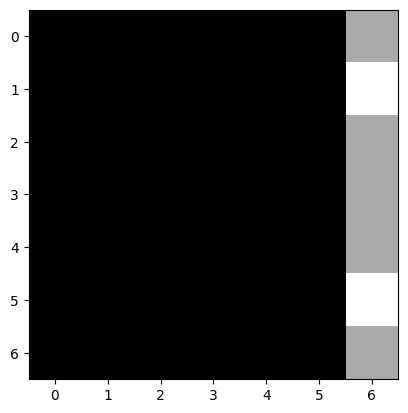

In [26]:
plt.imshow(relu_output, cmap='gray')

In [29]:
import numpy as np

# -------------------------
# Step 1: Input image — number "8"
# -------------------------
image = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1]
])
print("Input shape:", image.shape)

# -------------------------
# Step 2: Convolution (3x3 filter)
# -------------------------
kernel = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
])  # edge detector

output_shape = image.shape[0] - kernel.shape[0] + 1
conv_output = np.zeros((output_shape, output_shape))

for i in range(output_shape):
    for j in range(output_shape):
        region = image[i:i+3, j:j+3]
        conv_output[i, j] = np.sum(region * kernel)

print("\nAfter convolution:\n", conv_output)

# -------------------------
# Step 3: ReLU activation
# -------------------------
relu_output = np.maximum(conv_output, 0)
print("\nAfter ReLU:\n", relu_output)

# -------------------------
# Step 4: Max pooling (2x2, safe bounds)
# -------------------------
pool_size = 2
pooled_rows = relu_output.shape[0] // pool_size
pooled_cols = relu_output.shape[1] // pool_size
pooled_output = np.zeros((pooled_rows, pooled_cols))

for i in range(pooled_rows):
    for j in range(pooled_cols):
        region = relu_output[i*pool_size:(i+1)*pool_size, j*pool_size:(j+1)*pool_size]
        pooled_output[i, j] = np.max(region)

print("\nAfter max pooling:\n", pooled_output)

# -------------------------
# Step 5: Fully connected (flatten + output)
# -------------------------
flattened = pooled_output.flatten()
print("\nFlattened feature vector:", flattened)

# Tiny dense layer (2 output classes)
weights = np.random.randn(2, len(flattened))
biases = np.random.randn(2)
output = np.dot(weights, flattened) + biases

print("\nFinal output (class scores):", output)


Input shape: (9, 9)

After convolution:
 [[ 2.  3.  3.  3.  3.  3.  2.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [-2. -3. -3. -3. -3. -3. -2.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 2.  3.  3.  3.  3.  3.  2.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [-2. -3. -3. -3. -3. -3. -2.]]

After ReLU:
 [[2. 3. 3. 3. 3. 3. 2.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [2. 3. 3. 3. 3. 3. 2.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]

After max pooling:
 [[3. 3. 3.]
 [0. 0. 0.]
 [3. 3. 3.]]

Flattened feature vector: [3. 3. 3. 0. 0. 0. 3. 3. 3.]

Final output (class scores): [ -1.08109892 -10.82899479]


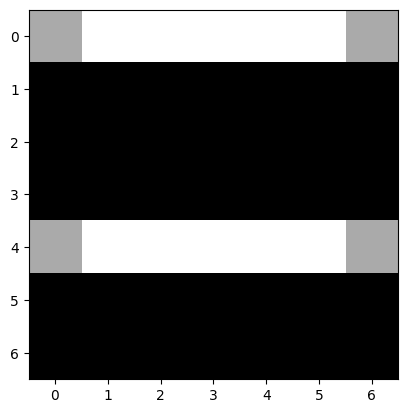

In [31]:
plt.imshow(relu_output, cmap='gray')